# Set GPU

In [1]:
import os

# You can only use one GPU at a time
os.environ["CUDA_VISIBLE_DEVICES"] = "6"
os.environ["OMP_NUM_THREADS"] = "16"
os.environ["MKL_NUM_THREADS"] = "16"

In [2]:
%%bash
echo "CUDA_VISIBLE_DEVICES: $CUDA_VISIBLE_DEVICES"
echo "OMP_NUM_THREADS: $OMP_NUM_THREADS"
echo "MKL_NUM_THREADS: $MKL_NUM_THREADS"

CUDA_VISIBLE_DEVICES: 6
OMP_NUM_THREADS: 16
MKL_NUM_THREADS: 16


In [3]:
import torch

if torch.cuda.is_available():
    torch.cuda.set_device(0)

    print("CUDA is available.")
    print(f"Number of CUDA devices: {torch.cuda.device_count()}")
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("CUDA is not available.")

CUDA is available.
Number of CUDA devices: 1
Current device: 0
Device name: NVIDIA A100-PCIE-40GB


In [4]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.datasets.folder import default_loader

from vv.data import ImageNetLoader, FFHQLoader, LSUNLoader

from vv.models.latent_diffusion_copy.vq_model import VQModel
from vv.models.vqgan_lc_copy.vq_model import VQModel

./venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Model

In [5]:
model_type = "F16"
data_type = "ffhq"

In [6]:
# Load your model checkpoint
if model_type == "F8":
    model_ckpt = "/path/to/additional_evaluations/ffhq_eval/models/vq_F8_K512_Z128_S64/version_11/checkpoints/epoch=14-step=1200000-val/total_loss=0.0487.ckpt"

    class_path = "vv.models.latent_diffusion_copy.vq_model.VQModel"
    model_args = {
        "learning_rate": 4.5e-06,
        "embed_dim": 128,
        "n_embed": 512,
        "split_quantizer": True,
        "num_spaces": 64,
        "distance_type": "l2",
        "ddconfig": {
            "double_z": False,
            "z_channels": 256,
            "resolution": 256,
            "in_channels": 3,
            "out_ch": 3,
            "ch": 128,
            "ch_mult": [1, 2, 2, 4],
            "num_res_blocks": 2,
            "attn_resolutions": [32],
            "dropout": 0.0,
        },
        "lossconfig": {
            "target": "vv.models.latent_diffusion_copy.dummy_loss.DummyLoss",
        },
    }
elif model_type == "F16":
    model_ckpt = "/path/to/additional_evaluations/ffhq_eval/models/F16_K128_Z256_S128/version_10/checkpoints/epoch=14-step=1200000-val/total_loss=0.1700.ckpt"

    class_path = "vv.models.latent_diffusion_copy.vq_model.VQModel"
    model_args = {
        "learning_rate": 4.5e-06,
        "embed_dim": 256,
        "n_embed": 128,
        "split_quantizer": True,
        "num_spaces": 128,
        "distance_type": "l2",
        "ddconfig": {
            "double_z": False,
            "z_channels": 256,
            "resolution": 256,
            "in_channels": 3,
            "out_ch": 3,
            "ch": 128,
            "ch_mult": [1, 1, 2, 2, 4],
            "num_res_blocks": 2,
            "attn_resolutions": [16],
            "dropout": 0.0,
        },
        "lossconfig": {
            "target": "vv.models.latent_diffusion_copy.dummy_loss.DummyLoss",
        },
    }

module_path, class_name = class_path.rsplit(".", 1)
_module = __import__(module_path, fromlist=[class_name])
module = getattr(_module, class_name)

print("Loading model...")
# Load checkpoint (ignore missing/mismatched keys if necessary)
model = module.load_from_checkpoint(
                model_ckpt,
                strict=False,  # Allow missing keys for backward compatibility
                **model_args
            )

# Move to GPU and set to eval mode
model = model.cuda().eval()

print("Model successfully loaded!")

Loading model...


./venv/lib/python3.11/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.1, which is newer than your current Lightning version: v2.5.0.post0


making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 256, 16, 16) = 65536 dimensions.
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
making attention of type 'vanilla' with 512 in_channels
If SplitVectorQuantiser used, it is used with distance type: l2


./venv/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['loss.perceptual_loss.scaling_layer.shift', 'loss.perceptual_loss.scaling_layer.scale', 'loss.perceptual_loss.net.slice1.0.weight', 'loss.perceptual_loss.net.slice1.0.bias', 'loss.perceptual_loss.net.slice1.2.weight', 'loss.perceptual_loss.net.slice1.2.bias', 'loss.perceptual_loss.net.slice2.5.weight', 'loss.perceptual_loss.net.slice2.5.bias', 'loss.perceptual_loss.net.slice2.7.weight', 'loss.perceptual_loss.net.slice2.7.bias', 'loss.perceptual_loss.net.slice3.10.weight', 'loss.perceptual_loss.net.slice3.10.bias', 'loss.perceptual_loss.net.slice3.12.weight', 'loss.perceptual_loss.net.slice3.12.bias', 'loss.perceptual_loss.net.slice3.14.weight', 'loss.perceptual_loss.net.slice3.14.bias', 'loss.perceptual_loss.net.slice4.17.weight', 'loss.perceptual_loss.net.slice4.17.bias', 'loss.perceptual_loss.net.slice4.19.weight', 'loss.perceptual_loss.net

Model successfully loaded!


In [7]:
# Load your model checkpoint
if model_type == "F8":
    model_ckpt_2 = "/path/to/additional_evaluations/ffhq_eval/models/vq_gan_lc/vqgan_lc_100k_F8_Z4/version_0/checkpoints/latest-step=0/vqgan-lc-100K-f8-dim4-lightning.ckpt"

    class_path_2 = "vv.models.vqgan_lc_copy.vq_model.VQModel"
    model_args_2 = {
        "learning_rate": 4.5e-06,
        "embed_dim": 4,
        "n_vision_words": 100000,
        "local_embedding_path": "/path/to/additional_evaluations/downloaded_models/models/vq_gan_lc/codebook-100K.pth",
        "tuning_codebook": 0,
        "use_cblinear": 1,
        "ddconfig": {
            "double_z": False,
            "z_channels": 256,
            "resolution": 256,
            "in_channels": 3,
            "out_ch": 3,
            "ch": 128,
            "ch_mult": [1, 2, 2, 4],
            "num_res_blocks": 2,
            "attn_resolutions": [16],
            "dropout": 0.0,
        },
        "lossconfig": {
            "target": "vv.models.latent_diffusion_copy.dummy_loss.DummyLoss",
        },
    }
elif model_type == "F16":
    model_ckpt_2 = "/path/to/additional_evaluations/ffhq_eval/models/vq_gan_lc/vqgan_lc_100k_F16_Z8/version_0/checkpoints/latest-step=0/vqgan-lc-100K-f16-dim8-lightning.ckpt"

    class_path_2 = "vv.models.vqgan_lc_copy.vq_model.VQModel"
    model_args_2 = {
        "learning_rate": 4.5e-06,
        "embed_dim": 8,
        "n_vision_words": 100000,
        "local_embedding_path": "/path/to/additional_evaluations/downloaded_models/models/vq_gan_lc/codebook-100K.pth",
        "tuning_codebook": 0,
        "use_cblinear": 1,
        "ddconfig": {
            "double_z": False,
            "z_channels": 256,
            "resolution": 256,
            "in_channels": 3,
            "out_ch": 3,
            "ch": 128,
            "ch_mult": [1, 1, 2, 2, 4],
            "num_res_blocks": 2,
            "attn_resolutions": [16],
            "dropout": 0.0,
        },
        "lossconfig": {
            "target": "vv.models.latent_diffusion_copy.dummy_loss.DummyLoss",
        },
    }

module_path_2, class_name_2 = class_path_2.rsplit(".", 1)
_module_2 = __import__(module_path_2, fromlist=[class_name_2])
module_2 = getattr(_module_2, class_name_2)

print("Loading model...")
# Load checkpoint (ignore missing/mismatched keys if necessary)
model_2 = module_2.load_from_checkpoint(
                model_ckpt_2,
                strict=False,  # Allow missing keys for backward compatibility
                **model_args_2
            )

# Move to GPU and set to eval mode
model_2 = model_2.cuda().eval()

print("Model successfully loaded!")

Loading model...
Working with z of shape (1, 256, 16, 16) = 65536 dimensions.
****Using Quantizer: org
****Using Fix CLIP/LLaMA Token Embedding****
Word Number:100000
Feature Dim:8


./venv/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['discriminator.main.0.weight', 'discriminator.main.0.bias', 'discriminator.main.2.weight', 'discriminator.main.3.weight', 'discriminator.main.3.bias', 'discriminator.main.3.running_mean', 'discriminator.main.3.running_var', 'discriminator.main.3.num_batches_tracked', 'discriminator.main.5.weight', 'discriminator.main.6.weight', 'discriminator.main.6.bias', 'discriminator.main.6.running_mean', 'discriminator.main.6.running_var', 'discriminator.main.6.num_batches_tracked', 'discriminator.main.8.weight', 'discriminator.main.8.bias', 'perceptual_loss.scaling_layer.shift', 'perceptual_loss.scaling_layer.scale', 'perceptual_loss.net.slice1.0.weight', 'perceptual_loss.net.slice1.0.bias', 'perceptual_loss.net.slice1.2.weight', 'perceptual_loss.net.slice1.2.bias', 'perceptual_loss.net.slice2.5.weight', 'perceptual_loss.net.slice2.5.bias', 'perceptual_

Model successfully loaded!


# Load Data

In [8]:
if data_type == "ffhq":
    data_module = FFHQLoader(
        resolution=256,
        test_split=0.14,
        train_val_split=0.8,
        #norm_values=(0.5, 0.5),
        batch_size=5,
        workers=16,
    )

    data_module.prepare_data()
    data_module.setup("validate")

    loader = data_module.val_dataloader()

elif data_type == "lsun":
    data_module = LSUNLoader(
        resolution=256,
        train_classes="train",
        val_classes="val",
        test_classes="test",
        #norm_values=(0.5, 0.5),
        batch_size=5,
        workers=16,
    )

    data_module.prepare_data()
    data_module.setup("validate")

    loader = data_module.val_dataloader()

renormalizer = data_module.get_renormalizer(target_max=1.0, target_min=-1.0)
renormalizer_plot= data_module.get_renormalizer(target_max=1.0, target_min=0.0)

batch = next(iter(loader))
print("Batch shape:", batch[0].shape)
print("Batch dtype:", batch[0].dtype)

Batch shape: torch.Size([5, 3, 256, 256])
Batch dtype: torch.float32


In [9]:
batch_m1p1 = renormalizer(batch[0])

print("Batch FFQH - Min:", batch[0].min().item(), "Max:", batch[0].max().item())
print("Batch FFQH 2 - Min:", batch_m1p1.min().item(), "Max:", batch_m1p1.max().item())

Batch FFQH - Min: -2.1179039478302 Max: 2.6225709915161133
Batch FFQH 2 - Min: -1.0 Max: 1.0


In [10]:
# M1P1 normalizer
data_module_ffqh_2 = FFHQLoader(
    norm_values=(0.5, 0.5),
)

renormalizer_plot_2 = data_module_ffqh_2.get_renormalizer(target_max=1.0, target_min=0.0)

# Test forward

In [11]:
model.eval()
model_2.eval()

with torch.no_grad():
    inputs_ffqh = batch[0].cuda()  # Move inputs to GPU
    outputs_ffqh = model(inputs_ffqh)  # Perform forward pass

with torch.no_grad():
    inputs_ffqh_2 = batch_m1p1.cuda()  # Move inputs to GPU
    outputs_ffqh_2 = model_2(inputs_ffqh_2, None, None)  # Perform forward pass

In [12]:
print(outputs_ffqh[0].shape)
print(outputs_ffqh_2.shape)

print("Batch FFQH - Min:", outputs_ffqh[0].min().item(), "Max:", outputs_ffqh[0].max().item())
print("Batch FFQH 2 - Min:", outputs_ffqh_2.min().item(), "Max:", outputs_ffqh_2.max().item())

torch.Size([5, 3, 256, 256])
torch.Size([5, 3, 256, 256])
Batch FFQH - Min: -2.5372962951660156 Max: 2.7379684448242188
Batch FFQH 2 - Min: -1.1182547807693481 Max: 1.136405348777771


# Forward pass

# Plotting

In [13]:
input = renormalizer_plot(batch[0].cpu()).clamp(0,1)
output = renormalizer_plot(outputs_ffqh[0].cpu()).clamp(0,1)
output_2 = renormalizer_plot_2(outputs_ffqh_2.cpu()).clamp(0,1)

print("Input - Min:", input.min().item(), "Max:", input.max().item())
print("Output - Min:", output.min().item(), "Max:", output.max().item())
print("Output 2 - Min:", output_2.min().item(), "Max:", output_2.max().item())

Input - Min: 0.0 Max: 1.0
Output - Min: 0.0 Max: 1.0
Output 2 - Min: 0.0 Max: 1.0


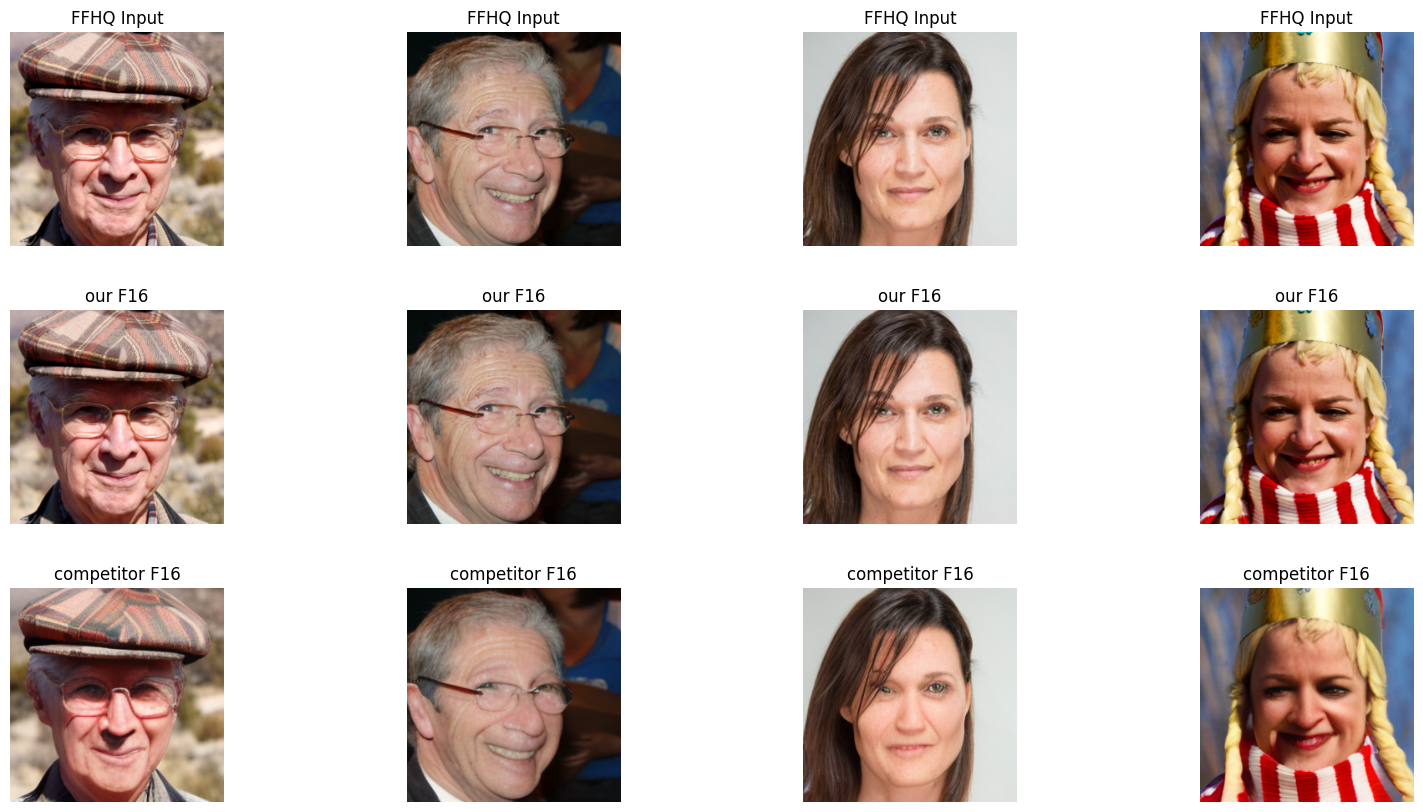

In [14]:
num_images = 4

# Corrected code
fig, axes = plt.subplots(3, num_images, figsize=(20, 10))  # Adjust figsize for larger sub-images

for i in range(num_images):
    # Plot input images (top row)
    axes[0, i].imshow(input[i].permute(1, 2, 0))
    axes[0, i].axis("off")
    axes[0, i].set_title("FFHQ Input")

    # Plot output images (bottom row)
    axes[1, i].imshow(output[i].permute(1, 2, 0))
    axes[1, i].axis("off")
    axes[1, i].set_title(f"our {model_type}")

    # Plot output images (bottom row)
    axes[2, i].imshow(output_2[i].permute(1, 2, 0))
    axes[2, i].axis("off")
    axes[2, i].set_title(f"competitor {model_type}")

plt.subplots_adjust(wspace=0.1, hspace=0.3)  # Adjust spacing between subplots
plt.show()